In [2]:
# Import libraries

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# don't truncate columns in pandas
pd.set_option('display.max_colwidth', None)
pd.options.display.max_rows = 300

In [3]:
# Define functions for data processing
def get_date(url):
    # GEDI02_A_2019262193446_O04362_01_T00992_02_003_01_V002_subsetted.h5 represents day 262 of 2019
    date_str = url.split('_')[2]
    year = int(date_str[:4]) 
    day = int(date_str[4:7]) 

    date = datetime(year, 1, 1) + timedelta(days = day - 1)
    return date.strftime('%Y-%m-%d')

def label_raster_val(value):
    if pd.isna(value):
        return 'Unknown'
        
    value = int(value)
    
    if 0 <= value <= 24:
        return f'deforestation_{2000 + value}'
    
    # Residual years (forgotten to be marked as deforestation)
    elif 50 <= value <= 64:
        return f'residual_{2010 + (value - 50)}'
    
    elif value == 91:
        return 'Hidrografia'
    elif value == 100:
        return 'Vegetacao Nativa'
    elif value == 101:
        return 'Nao Floresta'
    
    # Unknown
    else:
        return 'Unknown'

In [4]:
# Get the CSV from link - Process entire file in chunks
path = '../csv_files/final_for_aag_paper/gedi_prodes_2026_joined.csv'

chunk_size = 100000  # Process 100k rows at a time
chunks = []
row_offset = 0

print("Reading file in chunks...")
for i, chunk in enumerate(pd.read_csv(path, chunksize=chunk_size)):
    original_chunk_len = len(chunk)
    # Apply transformations to each chunk using defined functions
    for idx, row in chunk.iterrows():
        global_row = row_offset + idx + 1   # +1 if you want 1-based indexing

        try: 
            get_date(row['source_url'])
            label_raster_val(row['RASTERVALU'])
        except Exception as e:
            print("\nERROR DETECTED")
            print(f"Chunk: {i+1}")
            print(f"CSV Row Number: {global_row}")
            print("Row contents:")
            print(row)
            print("Error:", e)
            
            raise SystemExit("Stopping execution so you can debug.")
    
    chunk['date'] = chunk['source_url'].apply(get_date)
    chunk['land_class'] = chunk['RASTERVALU'].apply(label_raster_val)
    
    # Remove rows marked as deforestation_2007
    chunk = chunk[chunk['land_class'] != 'deforestation_2007']
    
    chunks.append(chunk)
    print(f"  Processed chunk {i+1} ({len(chunk)} rows)")

    row_offset += original_chunk_len

# Combine all chunks
df = pd.concat(chunks, ignore_index=True)
print(f"\nTotal rows loaded: {len(df):,}")
print(df.iloc[0])

Reading file in chunks...
  Processed chunk 1 (81005 rows)
  Processed chunk 2 (90952 rows)
  Processed chunk 3 (78955 rows)
  Processed chunk 4 (98038 rows)
  Processed chunk 5 (85073 rows)
  Processed chunk 6 (97225 rows)
  Processed chunk 7 (84215 rows)
  Processed chunk 8 (91761 rows)
  Processed chunk 9 (89041 rows)
  Processed chunk 10 (78601 rows)
  Processed chunk 11 (95257 rows)
  Processed chunk 12 (82075 rows)
  Processed chunk 13 (80957 rows)
  Processed chunk 14 (84176 rows)
  Processed chunk 15 (74112 rows)
  Processed chunk 16 (89239 rows)
  Processed chunk 17 (78351 rows)
  Processed chunk 18 (87696 rows)
  Processed chunk 19 (93784 rows)
  Processed chunk 20 (80711 rows)
  Processed chunk 21 (94052 rows)
  Processed chunk 22 (92428 rows)
  Processed chunk 23 (76912 rows)
  Processed chunk 24 (79862 rows)
  Processed chunk 25 (69160 rows)
  Processed chunk 26 (76606 rows)
  Processed chunk 27 (94130 rows)
  Processed chunk 28 (87220 rows)
  Processed chunk 29 (83644 row

In [16]:
# Add temporal columns for analysis
df['year'] = pd.to_datetime(df['date']).dt.year
df['month'] = pd.to_datetime(df['date']).dt.month

print(f"\nUnique land classes found:")
print(df['land_class'].unique())


Unique land classes found:
['Vegetacao Nativa' 'deforestation_2019' 'deforestation_2017'
 'deforestation_2020' 'deforestation_2018' 'deforestation_2016'
 'deforestation_2021' 'Hidrografia' 'deforestation_2011'
 'deforestation_2024' 'deforestation_2015' 'deforestation_2012'
 'deforestation_2022' 'deforestation_2008' 'deforestation_2009'
 'deforestation_2010' 'deforestation_2014' 'Unknown' 'residual_2018'
 'deforestation_2023' 'deforestation_2013' 'deforestation_2000'
 'residual_2010' 'residual_2024' 'deforestation_2004' 'residual_2015'
 'deforestation_2002' 'deforestation_2006' 'residual_2016' 'residual_2019'
 'residual_2023' 'residual_2017' 'residual_2011' 'residual_2020'
 'residual_2013' 'residual_2014' 'residual_2012' 'residual_2021'
 'residual_2022']


In [17]:
# Print the earliest date and latest date
print("Earliest date in dataset:", df['date'].min())
print("Latest date in dataset:", df['date'].max())

Earliest date in dataset: 2019-05-01
Latest date in dataset: 2025-02-19


In [20]:
# Print land class distribution
print("\n=== LAND CLASS DISTRIBUTION ===")
land_class_counts = df['land_class'].value_counts()
print(land_class_counts)

print(f"\nTotal rows: {len(df):,}")


=== LAND CLASS DISTRIBUTION ===
land_class
Vegetacao Nativa      39208359
deforestation_2020      657547
Hidrografia             262141
deforestation_2022      169127
deforestation_2008      167213
deforestation_2019      138477
deforestation_2021      108343
deforestation_2023      106902
deforestation_2010      104501
deforestation_2009      102854
deforestation_2016       84377
deforestation_2018       84197
deforestation_2000       82475
deforestation_2024       77982
deforestation_2011       76511
deforestation_2017       73894
deforestation_2013       65664
deforestation_2015       62483
deforestation_2014       53944
deforestation_2012       46643
residual_2015            18016
deforestation_2002       15110
Unknown                  14385
deforestation_2006       11586
deforestation_2004       11053
residual_2019             6323
residual_2010             3605
residual_2024             3333
residual_2016             2612
residual_2023             1397
residual_2011             

In [19]:
# Get the number of negative rh values

total_deforested_rows = len(df[df['land_class'].str.startswith('deforestation_')])
print("Total rows marked as deforested: ", total_deforested_rows)

overall_negative_rh_count = len(df[
    (df['rh25'] < 0) |
    (df['rh50'] < 0) |
    (df['rh75'] < 0) |
    (df['rh95'] < 0)
])

rh95_negative_count = len(df[df['rh95'] < 0])
rh_75_negative_count = len(df[df['rh75'] < 0])
rh50_negative_count = len(df[df['rh50'] < 0])
rh25_negative_count = len(df[df['rh25'] < 0])

print("OVERALL total rows with negative RH values: ", overall_negative_rh_count)
print("# rows with negative RH95 values: ", rh95_negative_count)
print("# rows with negative RH75 values: ", rh_75_negative_count)
print("# rows with negative RH50 values: ", rh50_negative_count)
print("# rows with negative RH25 values: ", rh25_negative_count)


deforestation_negative_rh_count = len(df[
    (df['land_class'].str.startswith('deforestation_')) & 
    (
        (df['rh25'] < 0) |
        (df['rh50'] < 0) |
        (df['rh75'] < 0) |
        (df['rh95'] < 0)
    )
])

deforested_rh95_negative_count = len(df[
    (df['land_class'].str.startswith('deforestation_')) & 
    (df['rh95'] < 0)
])
deforested_rh75_negative_count = len(df[
    (df['land_class'].str.startswith('deforestation_')) & 
    (df['rh75'] < 0)
])
deforested_rh50_negative_count = len(df[
    (df['land_class'].str.startswith('deforestation_')) & 
    (df['rh50'] < 0)
])
deforested_rh25_negative_count = len(df[
    (df['land_class'].str.startswith('deforestation_')) & 
    (df['rh25'] < 0)
])

print("OVERALL rows marked as deforested with negative RH values: ", deforestation_negative_rh_count)
print("# rows marked as deforested with negative RH95 values: ", deforested_rh95_negative_count)
print("# rows marked as deforested with negative RH75 values: ", deforested_rh75_negative_count)
print("# rows marked as deforested with negative RH50 values: ", deforested_rh50_negative_count)
print("# rows marked as deforested with negative RH25 values: ", deforested_rh25_negative_count)

Total rows marked as deforested:  2300883
OVERALL total rows with negative RH values:  6132213
# rows with negative RH95 values:  0
# rows with negative RH75 values:  244
# rows with negative RH50 values:  1200400
# rows with negative RH25 values:  6132213
OVERALL rows marked as deforested with negative RH values:  1204791
# rows marked as deforested with negative RH95 values:  0
# rows marked as deforested with negative RH75 values:  28
# rows marked as deforested with negative RH50 values:  354247
# rows marked as deforested with negative RH25 values:  1204791


In [21]:
# Get statistics for deforested rows with any negative RH value
only_negative_rh_deforested = df[
    (df['land_class'].str.startswith('deforestation_')) &
    (
        (df['rh25'] < 0) |
        (df['rh50'] < 0) |
        (df['rh75'] < 0) |
        (df['rh95'] < 0)
    )
]

print(len(only_negative_rh_deforested))
avg_rh25_neg_rh_deforested = only_negative_rh_deforested['rh25'].mean()
avg_rh50_neg_rh_deforested = only_negative_rh_deforested['rh50'].mean()
avg_rh75_neg_rh_deforested = only_negative_rh_deforested['rh75'].mean()
avg_rh95_neg_rh_deforested = only_negative_rh_deforested['rh95'].mean()

print(f"Average rh25 values for deforested points with negative rh: {avg_rh25_neg_rh_deforested}")
print(f"Average rh50 values for deforested points with negative rh: {avg_rh50_neg_rh_deforested}")
print(f"Average rh75 values for deforested points with negative rh: {avg_rh75_neg_rh_deforested}")
print(f"Average rh95 values for deforested points with negative rh: {avg_rh95_neg_rh_deforested}")


1204791
Average rh25 values for deforested points with negative rh: -1.3846321810172881
Average rh50 values for deforested points with negative rh: 0.5260356609569627
Average rh75 values for deforested points with negative rh: 3.14178383636664
Average rh95 values for deforested points with negative rh: 8.24951548442842


In [22]:
# Global colors variable
colors = ['blue', 'orange', 'green', 'red']

# Global metrics variable
metrics = ['rh25', 'rh50', 'rh75', 'rh95']

In [23]:
# Create deforestation_data dataframe + useful vars based off it
deforestation_data = df[df['land_class'].str.startswith('deforestation_', na=False)].copy()
deforestation_data['deforestation_year'] = deforestation_data['land_class'].str.replace('deforestation_','').astype(int)
deforestation_data['years_since_deforestation'] = deforestation_data['year'] - deforestation_data['deforestation_year']
deforestation_data = deforestation_data[deforestation_data['years_since_deforestation'] >= 0]

#median rh25, 50, 75, 95 for each year
median_rh_by_year = deforestation_data.groupby('deforestation_year')[metrics].median()
#mean rh25, 50, 75, 95 for each year
mean_rh_by_year = deforestation_data.groupby('deforestation_year')[metrics].mean()
#median rh25, 50, 75, 95 for years since deforestation
median_rh_by_years_since_deforestation = deforestation_data.groupby('years_since_deforestation')[metrics].median()

# Add residual columns
for metric in metrics:
    median_values = deforestation_data['deforestation_year'].map(median_rh_by_year[metric])
    deforestation_data[f'{metric}_residual_median'] = deforestation_data[metric] - median_values

for metric in metrics:
    mean_values = deforestation_data['deforestation_year'].map(mean_rh_by_year[metric])
    deforestation_data[f'{metric}_residual_mean'] = deforestation_data[metric] - mean_values

for metric in metrics:
    median_values = deforestation_data['years_since_deforestation'].map(median_rh_by_years_since_deforestation[metric])
    deforestation_data[f'{metric}_residual_median_years_since_deforestation'] = deforestation_data[metric] - median_values


print("Total rows before removing negative RH values: ", len(deforestation_data))

# Remove rows with negative RH values
pos_rh_deforestation_data = deforestation_data[
    (deforestation_data['rh25'] >= 0) & 
    (deforestation_data['rh50'] >= 0) & 
    (deforestation_data['rh75'] >= 0) & 
    (deforestation_data['rh95'] >= 0)
]

print("Total rows after removing negative RH values: ", len(pos_rh_deforestation_data))

regrowth_stats = pos_rh_deforestation_data.groupby('years_since_deforestation')[metrics].mean()

deforestation_years = deforestation_data['land_class'].str.replace('deforestation_', '').astype(int)

Total rows before removing negative RH values:  1812402
Total rows after removing negative RH values:  746258


In [24]:
deforestation_data.head()
pos_rh_deforestation_data.head()

,source_url,RASTERVALU,latitude,longitude,rh25,rh50,rh75,rh95,sensitivity,date,...,rh75_residual_median,rh95_residual_median,rh25_residual_mean,rh50_residual_mean,rh75_residual_mean,rh95_residual_mean,rh25_residual_median_years_since_deforestation,rh50_residual_median_years_since_deforestation,rh75_residual_median_years_since_deforestation,rh95_residual_median_years_since_deforestation
68,https://harmony.earthdata.nasa.gov/service-results/harmony-prod-staging/public/537acc55-37e7-4dc4-9d98-0424663735e5/154660185/GEDI02_A_2019121154951_O02171_04_T03448_02_003_01_V002_subsetted.h5,19.0,-5.861696,-57.715751,8.72,15.76,21.91,28.73,0.980798,2019-05-01,...,18.19,19.02,7.075403,10.283184,12.288109,13.286382,9.01,13.27,14.63,13.90
69,https://harmony.earthdata.nasa.gov/service-results/harmony-prod-staging/public/537acc55-37e7-4dc4-9d98-0424663735e5/154660185/GEDI02_A_2019121154951_O02171_04_T03448_02_003_01_V002_subsetted.h5,19.0,-5.862554,-57.715132,1.94,7.49,12.43,16.18,0.965986,2019-05-01,...,8.71,6.47,0.295403,2.013184,2.808109,0.736382,2.23,5.00,5.15,1.35
70,https://harmony.earthdata.nasa.gov/service-results/harmony-prod-staging/public/537acc55-37e7-4dc4-9d98-0424663735e5/154660185/GEDI02_A_2019121154951_O02171_04_T03448_02_003_01_V002_subsetted.h5,19.0,-5.863377,-57.714546,2.21,3.97,5.84,8.31,0.918474,2019-05-01,...,2.12,-1.40,0.565403,-1.506816,-3.781891,-7.133618,2.50,1.48,-1.44,-6.52
71,https://harmony.earthdata.nasa.gov/service-results/harmony-prod-staging/public/537acc55-37e7-4dc4-9d98-0424663735e5/154660185/GEDI02_A_2019121154951_O02171_04_T03448_02_003_01_V002_subsetted.h5,19.0,-5.863813,-57.714231,3.33,8.57,12.09,15.32,0.969871,2019-05-01,...,8.37,5.61,1.685403,3.093184,2.468109,-0.123618,3.62,6.08,4.81,0.49
72,https://harmony.earthdata.nasa.gov/service-results/harmony-prod-staging/public/537acc55-37e7-4dc4-9d98-0424663735e5/154660185/GEDI02_A_2019121154951_O02171_04_T03448_02_003_01_V002_subsetted.h5,19.0,-5.864225,-57.713937,1.64,3.55,5.61,6.74,0.969389,2019-05-01,...,1.89,-2.97,-0.004597,-1.926816,-4.011891,-8.703618,1.93,1.06,-1.67,-8.09


In [17]:
# save both the dataframes to csv
df.to_csv('../csv_files/final_for_aag_paper/gedi_prodes_2026_joined_with_dates_and_classes.csv', index=False)
# deforestation_data.to_csv('../csv_files/final_for_aag_paper/deforestation_data_with_residuals.csv', index=False)
# pos_rh_deforestation_data.to_csv('../csv_files/final_for_aag_paper/pos_rh_deforestation_data_with_residuals.csv', index=False)

## Data Visualization

Create histograms and charts from the complete dataset.

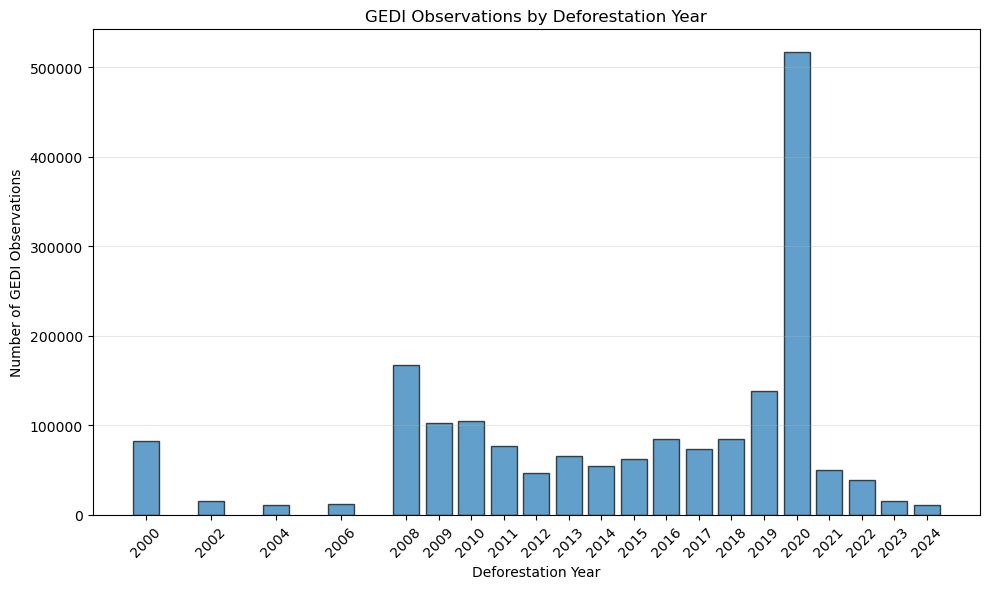


Deforestation observations: 1812402
Year range: 2000 - 2024


In [25]:
year_counts = deforestation_data['deforestation_year'].value_counts().sort_index()
plt.figure(figsize=(10, 6))
plt.bar(year_counts.index, year_counts.values, edgecolor='black', alpha=0.7)
plt.xlabel('Deforestation Year')
plt.ylabel('Number of GEDI Observations')
plt.title('GEDI Observations by Deforestation Year')
plt.xticks(year_counts.index, rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nDeforestation observations: {len(deforestation_data)}")
print(f"Year range: {deforestation_years.min()} - {deforestation_years.max()}")

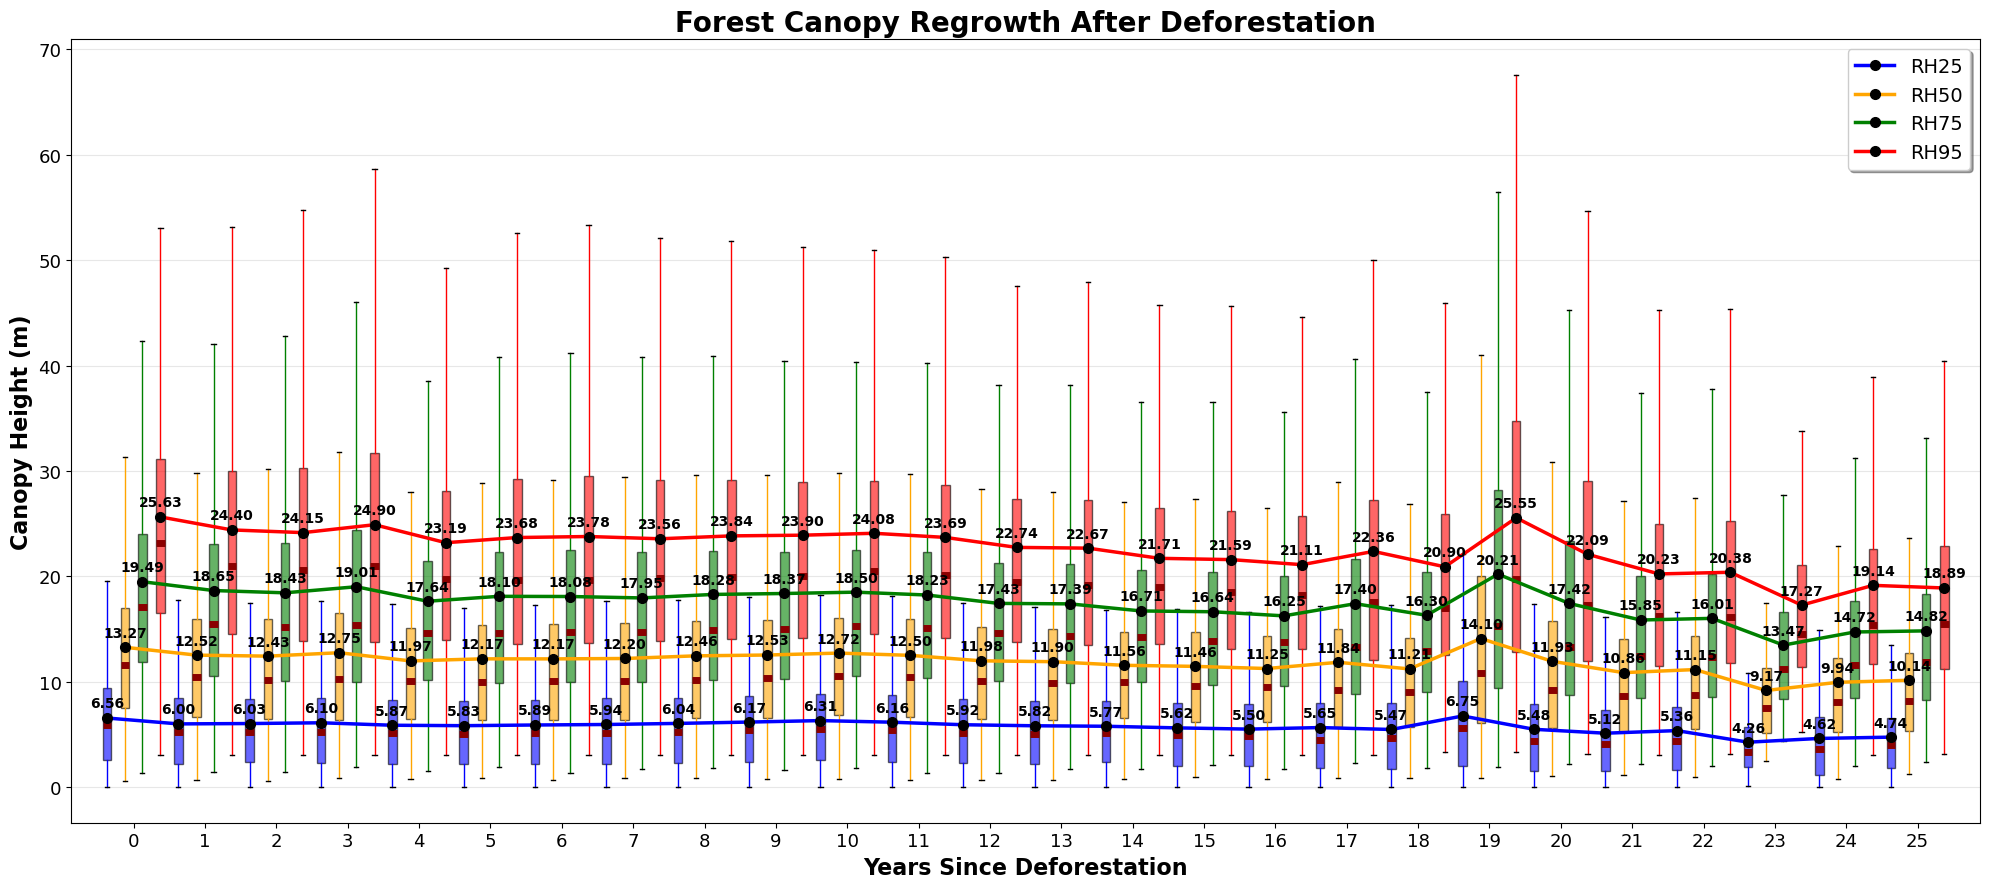

In [26]:
# Show all charts combined with boxplots side by side
fig, ax = plt.subplots(figsize=(20, 9))
years_list = sorted(pos_rh_deforestation_data['years_since_deforestation'].unique())

width = 0.15
offsets = [-2.5*width, -0.8*width, 0.8*width, 2.5*width]

for i, (metric, color, label, offset) in enumerate(zip(metrics, colors, ['RH25', 'RH50', 'RH75', 'RH95'], offsets)):
    data_by_year = [pos_rh_deforestation_data[pos_rh_deforestation_data['years_since_deforestation'] == year][metric].dropna() 
                    for year in years_list]
    
    # Position boxplots with offset
    positions = [year + offset for year in years_list]
    
    # Create boxplot
    bp = ax.boxplot(data_by_year, positions=positions, widths=width*0.8, patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.6),
                    medianprops=dict(color='darkred', linewidth=5),
                    whiskerprops=dict(color=color),
                    showfliers=False)
    
    # Overlay line connecting means
    means = regrowth_stats[metric]
    ax.plot(positions, means, marker='o', color=color, markerfacecolor='black', markeredgecolor='black', 
            linewidth=2.5, markersize=7, zorder=3, label=label)

    # Label each point with its value
    for x, y in zip(positions, means):
        ax.text(x, y + 1, f'{y:.2f}', fontsize=10, ha='center', color='black', fontweight='bold')

ax.set_xlabel('Years Since Deforestation', fontsize=16, fontweight='bold')
ax.set_ylabel('Canopy Height (m)', fontsize=16, fontweight='bold')
ax.set_title('Forest Canopy Regrowth After Deforestation', fontsize=20, fontweight='bold')
ax.legend(fontsize=14, loc='upper right', shadow=True)
ax.grid(True, alpha=0.3, axis='y')
ax.set_xticks(years_list)
ax.set_xticklabels([int(year) for year in years_list], fontsize=13)
ax.tick_params(axis='y', labelsize=13)

plt.tight_layout()
plt.show()


Mean canopy heights by years since deforestation:
years_since_deforestation
0     13.27
1     12.52
2     12.43
3     12.75
4     11.97
5     12.17
6     12.17
7     12.20
8     12.46
9     12.53
10    12.72
11    12.50
12    11.98
13    11.90
14    11.56
15    11.46
16    11.25
17    11.84
18    11.21
19    14.10
20    11.93
21    10.86
22    11.15
23     9.17
24     9.94
25    10.14
Name: rh50, dtype: float64


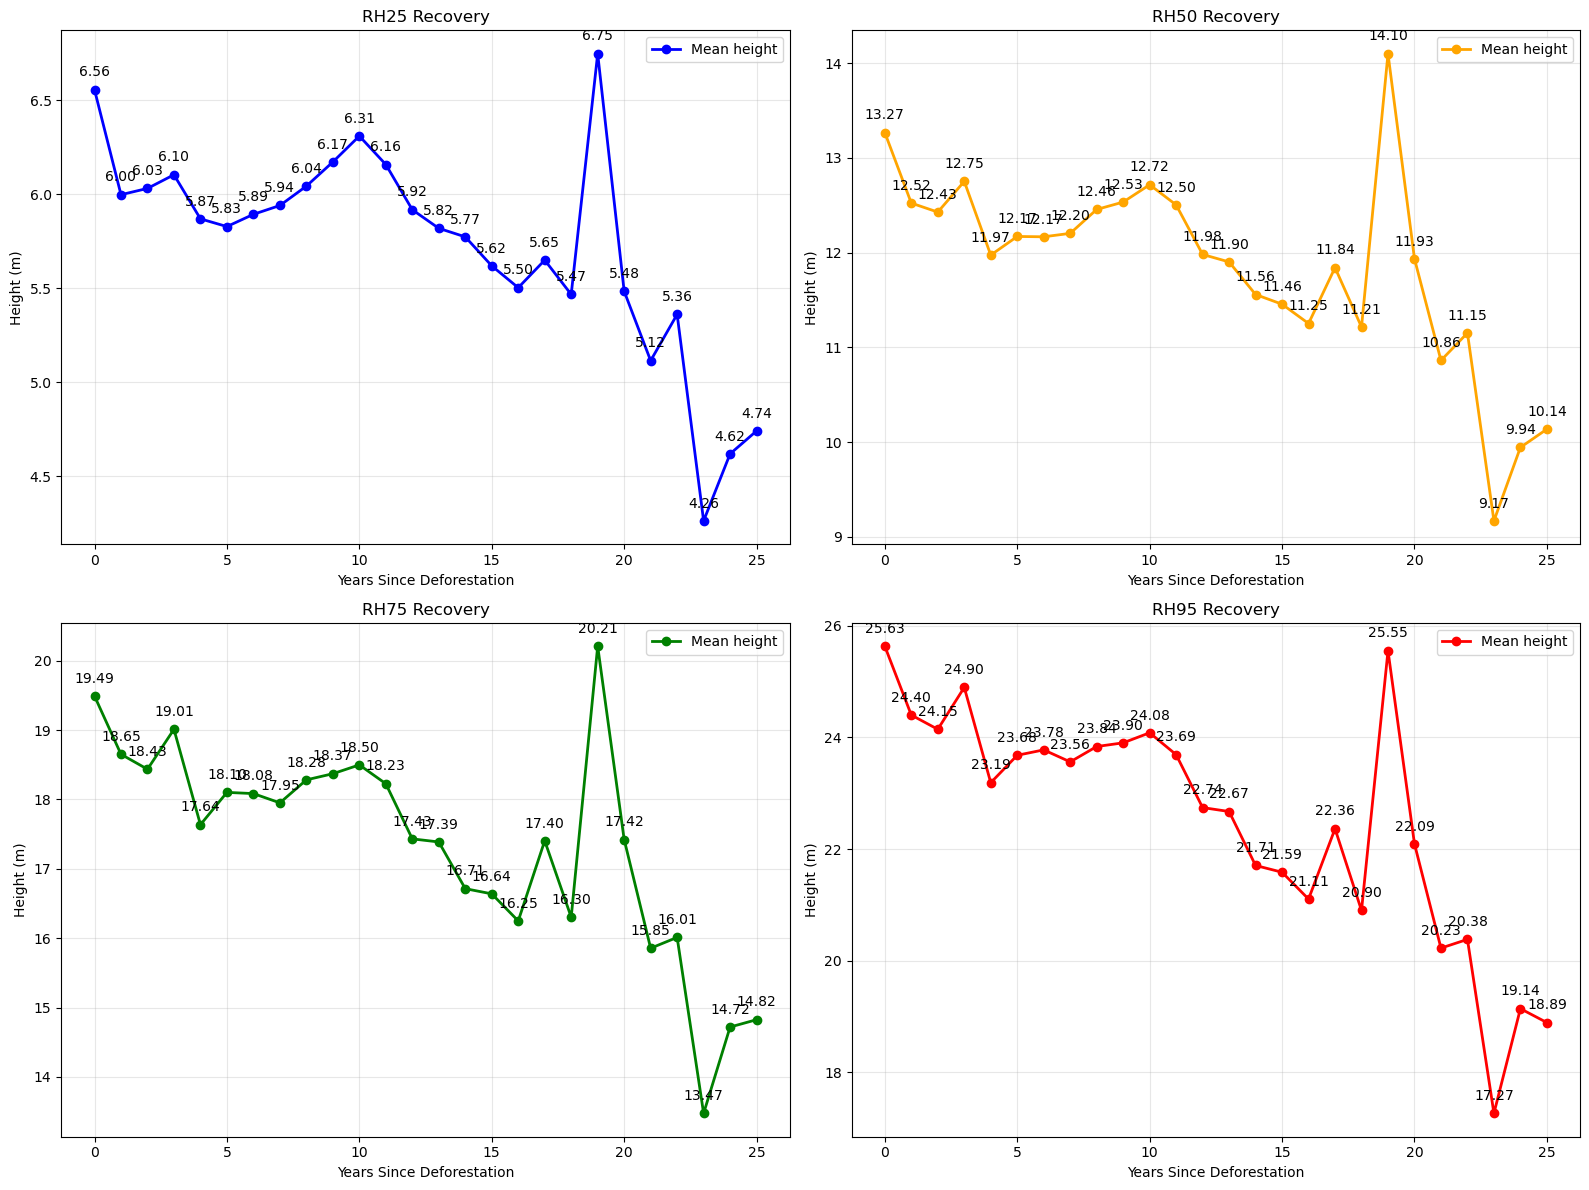

In [27]:
print("\nMean canopy heights by years since deforestation:")
print(regrowth_stats['rh50'].round(2))

# Visualization: Height recovery over time (simple line plots)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['rh25', 'rh50', 'rh75', 'rh95']
titles = ['RH25 Recovery', 'RH50 Recovery', 'RH75 Recovery', 'RH95 Recovery']

for idx, (metric, title, color) in enumerate(zip(metrics, titles, colors)):
    ax = axes[idx // 2, idx % 2]
    
    years = regrowth_stats.index
    means = regrowth_stats[metric]
    
    # plot mean
    ax.plot(years, means, marker='o', linewidth=2, color=color, label='Mean height')
    
    ax.set_xlabel('Years Since Deforestation')
    ax.set_ylabel('Height (m)')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()

    #label each point with its value
    for x, y in zip(years, means):
        y_offset = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.02
        ax.text(x, y + y_offset, f'{y:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

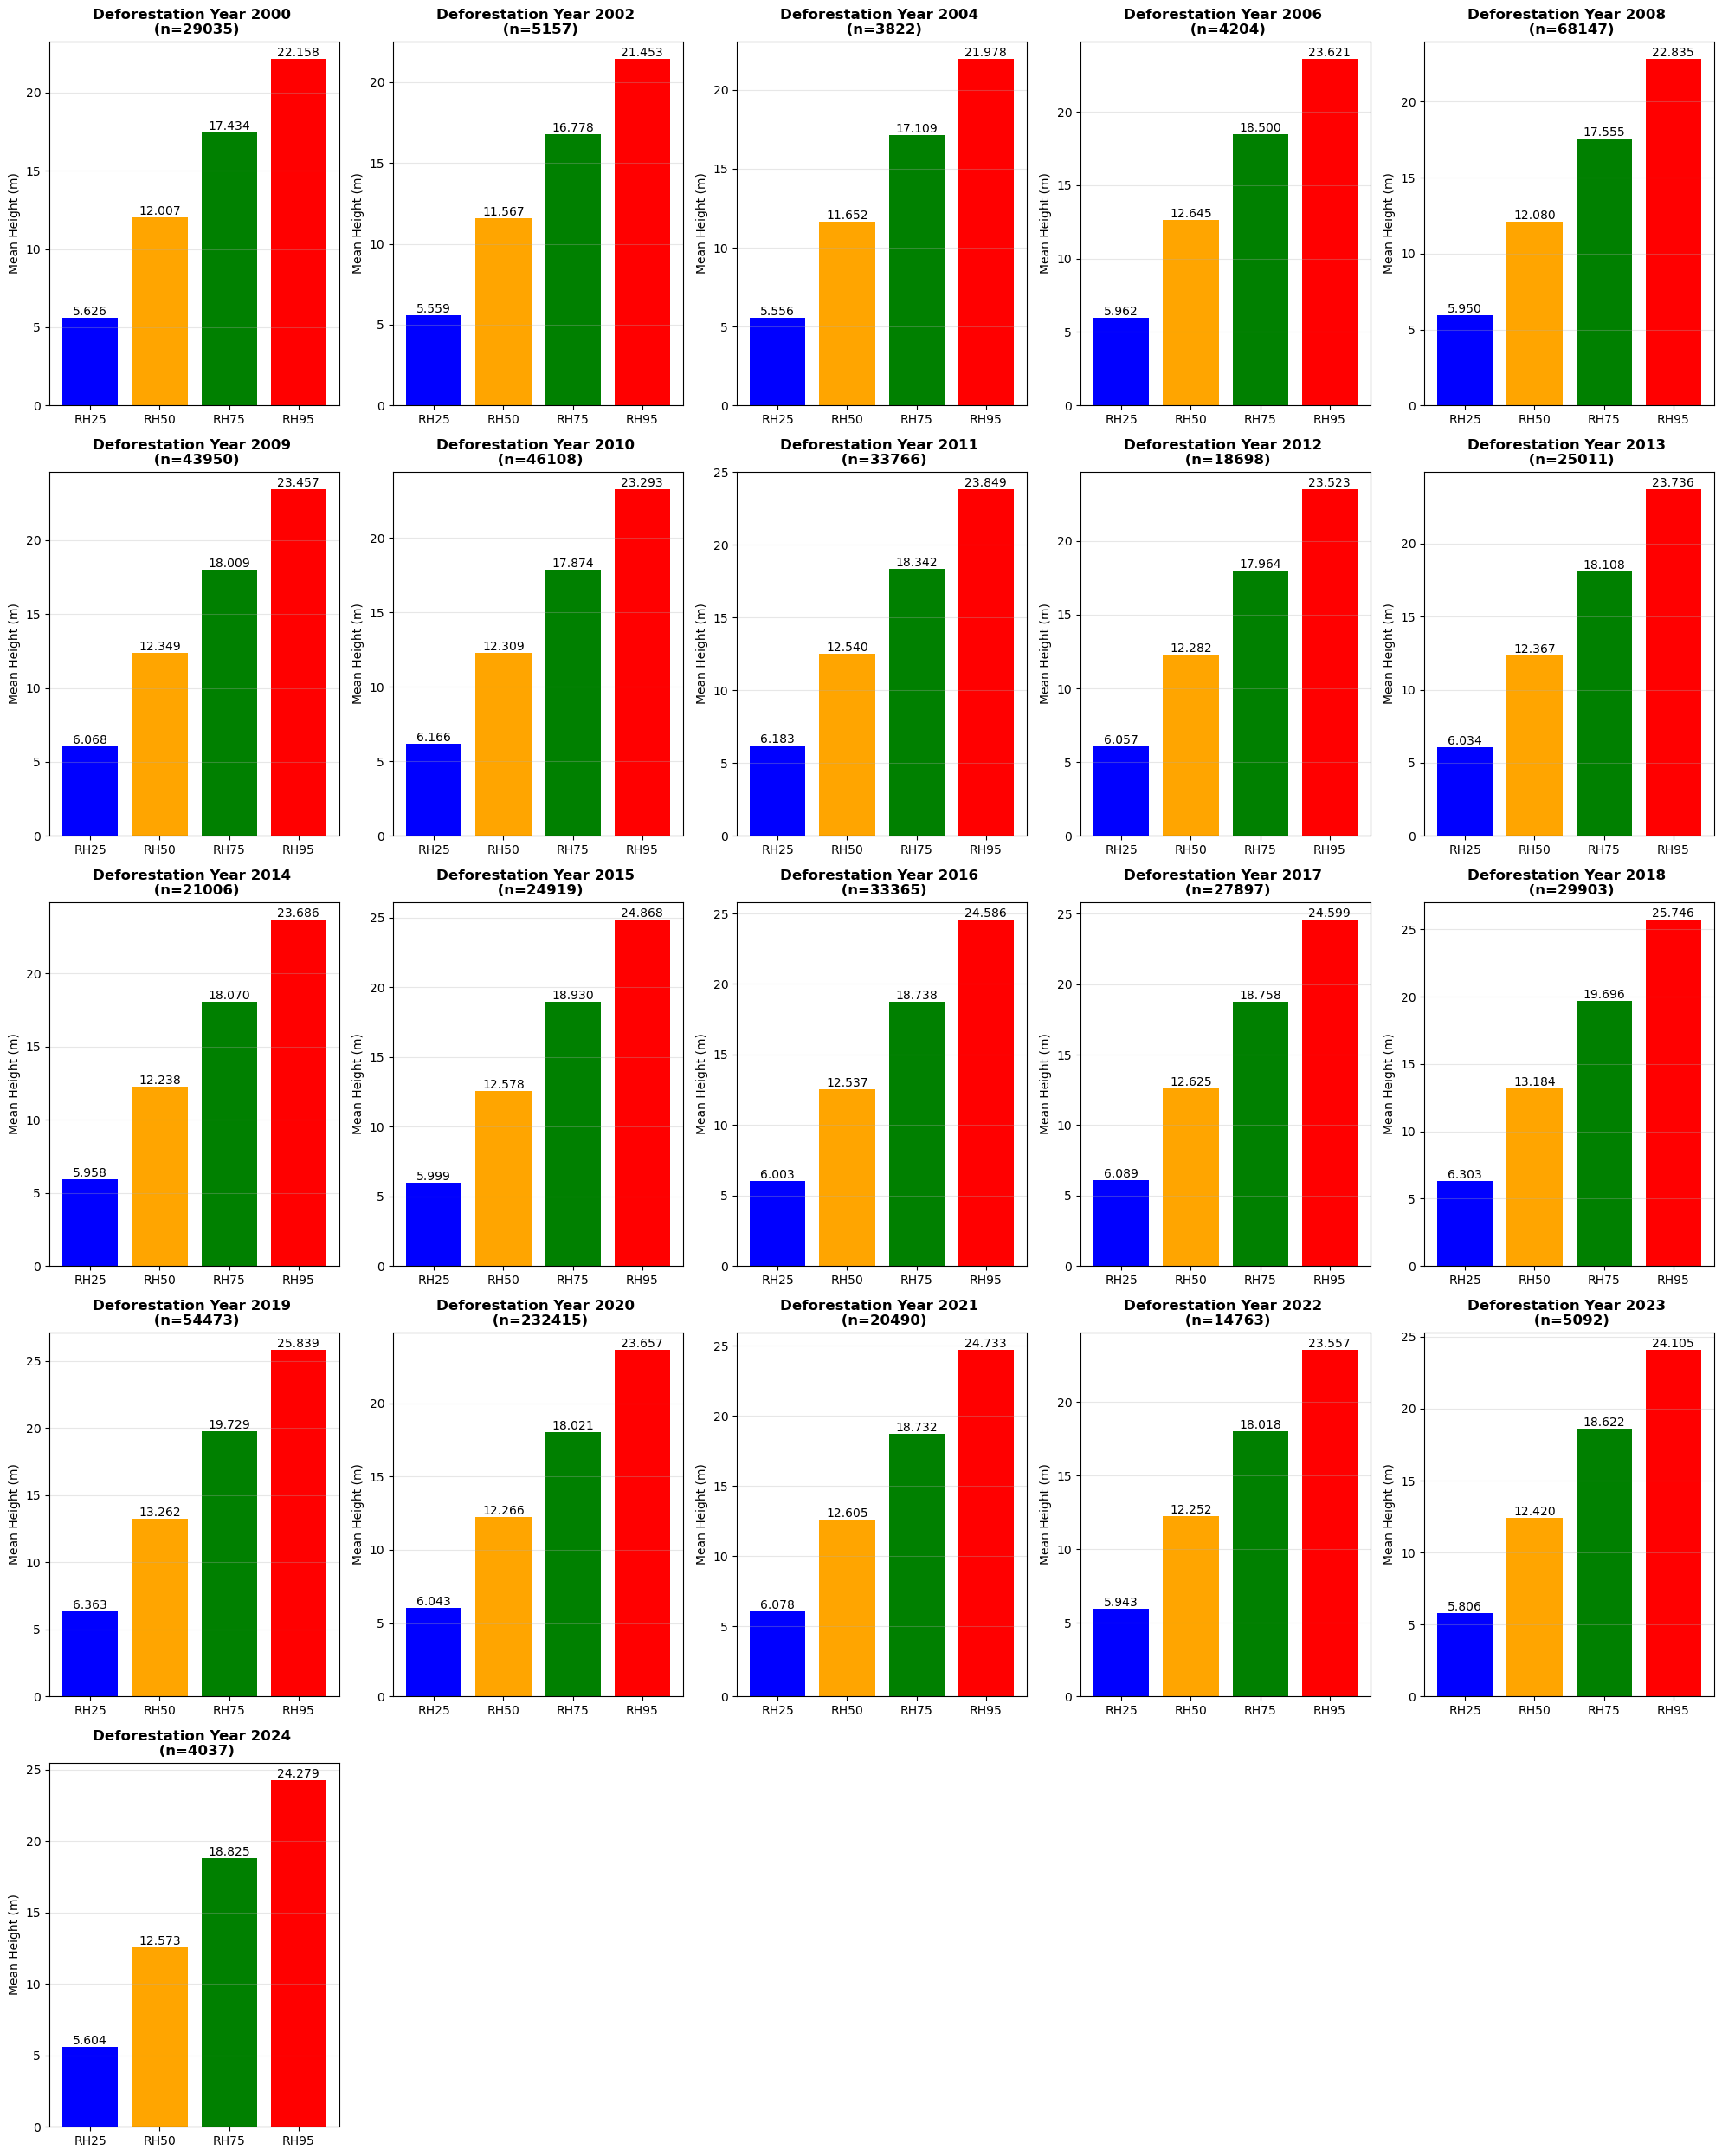

In [28]:
# Bar charts for each deforestation year showing all 4 rh metrics
years = sorted(pos_rh_deforestation_data['deforestation_year'].unique())

# rows/columns needed for subplots
n_years = len(years)
n_cols = 5
n_rows = (n_years + n_cols - 1) // n_cols 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()  # Flatten to 1D array

for idx, year in enumerate(years):
    ax = axes[idx]
    
    # Get data for this year
    year_data = pos_rh_deforestation_data[pos_rh_deforestation_data['deforestation_year'] == year]
    
    # Calc mean heights for each rh value
    mean_heights = [year_data[metric].mean() for metric in metrics]
    
    # Create bar chart
    bars = ax.bar(['RH25', 'RH50', 'RH75', 'RH95'], mean_heights, 
                   color=colors)
    
    ax.set_ylabel('Mean Height (m)')
    ax.set_title(f'Deforestation Year {year} \n (n={len(year_data)})', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    # label bars with values
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f')


# remove unused plots
for j in range(len(years), n_cols*n_rows):
    axes[j].axis("off")

plt.tight_layout() 
plt.show()

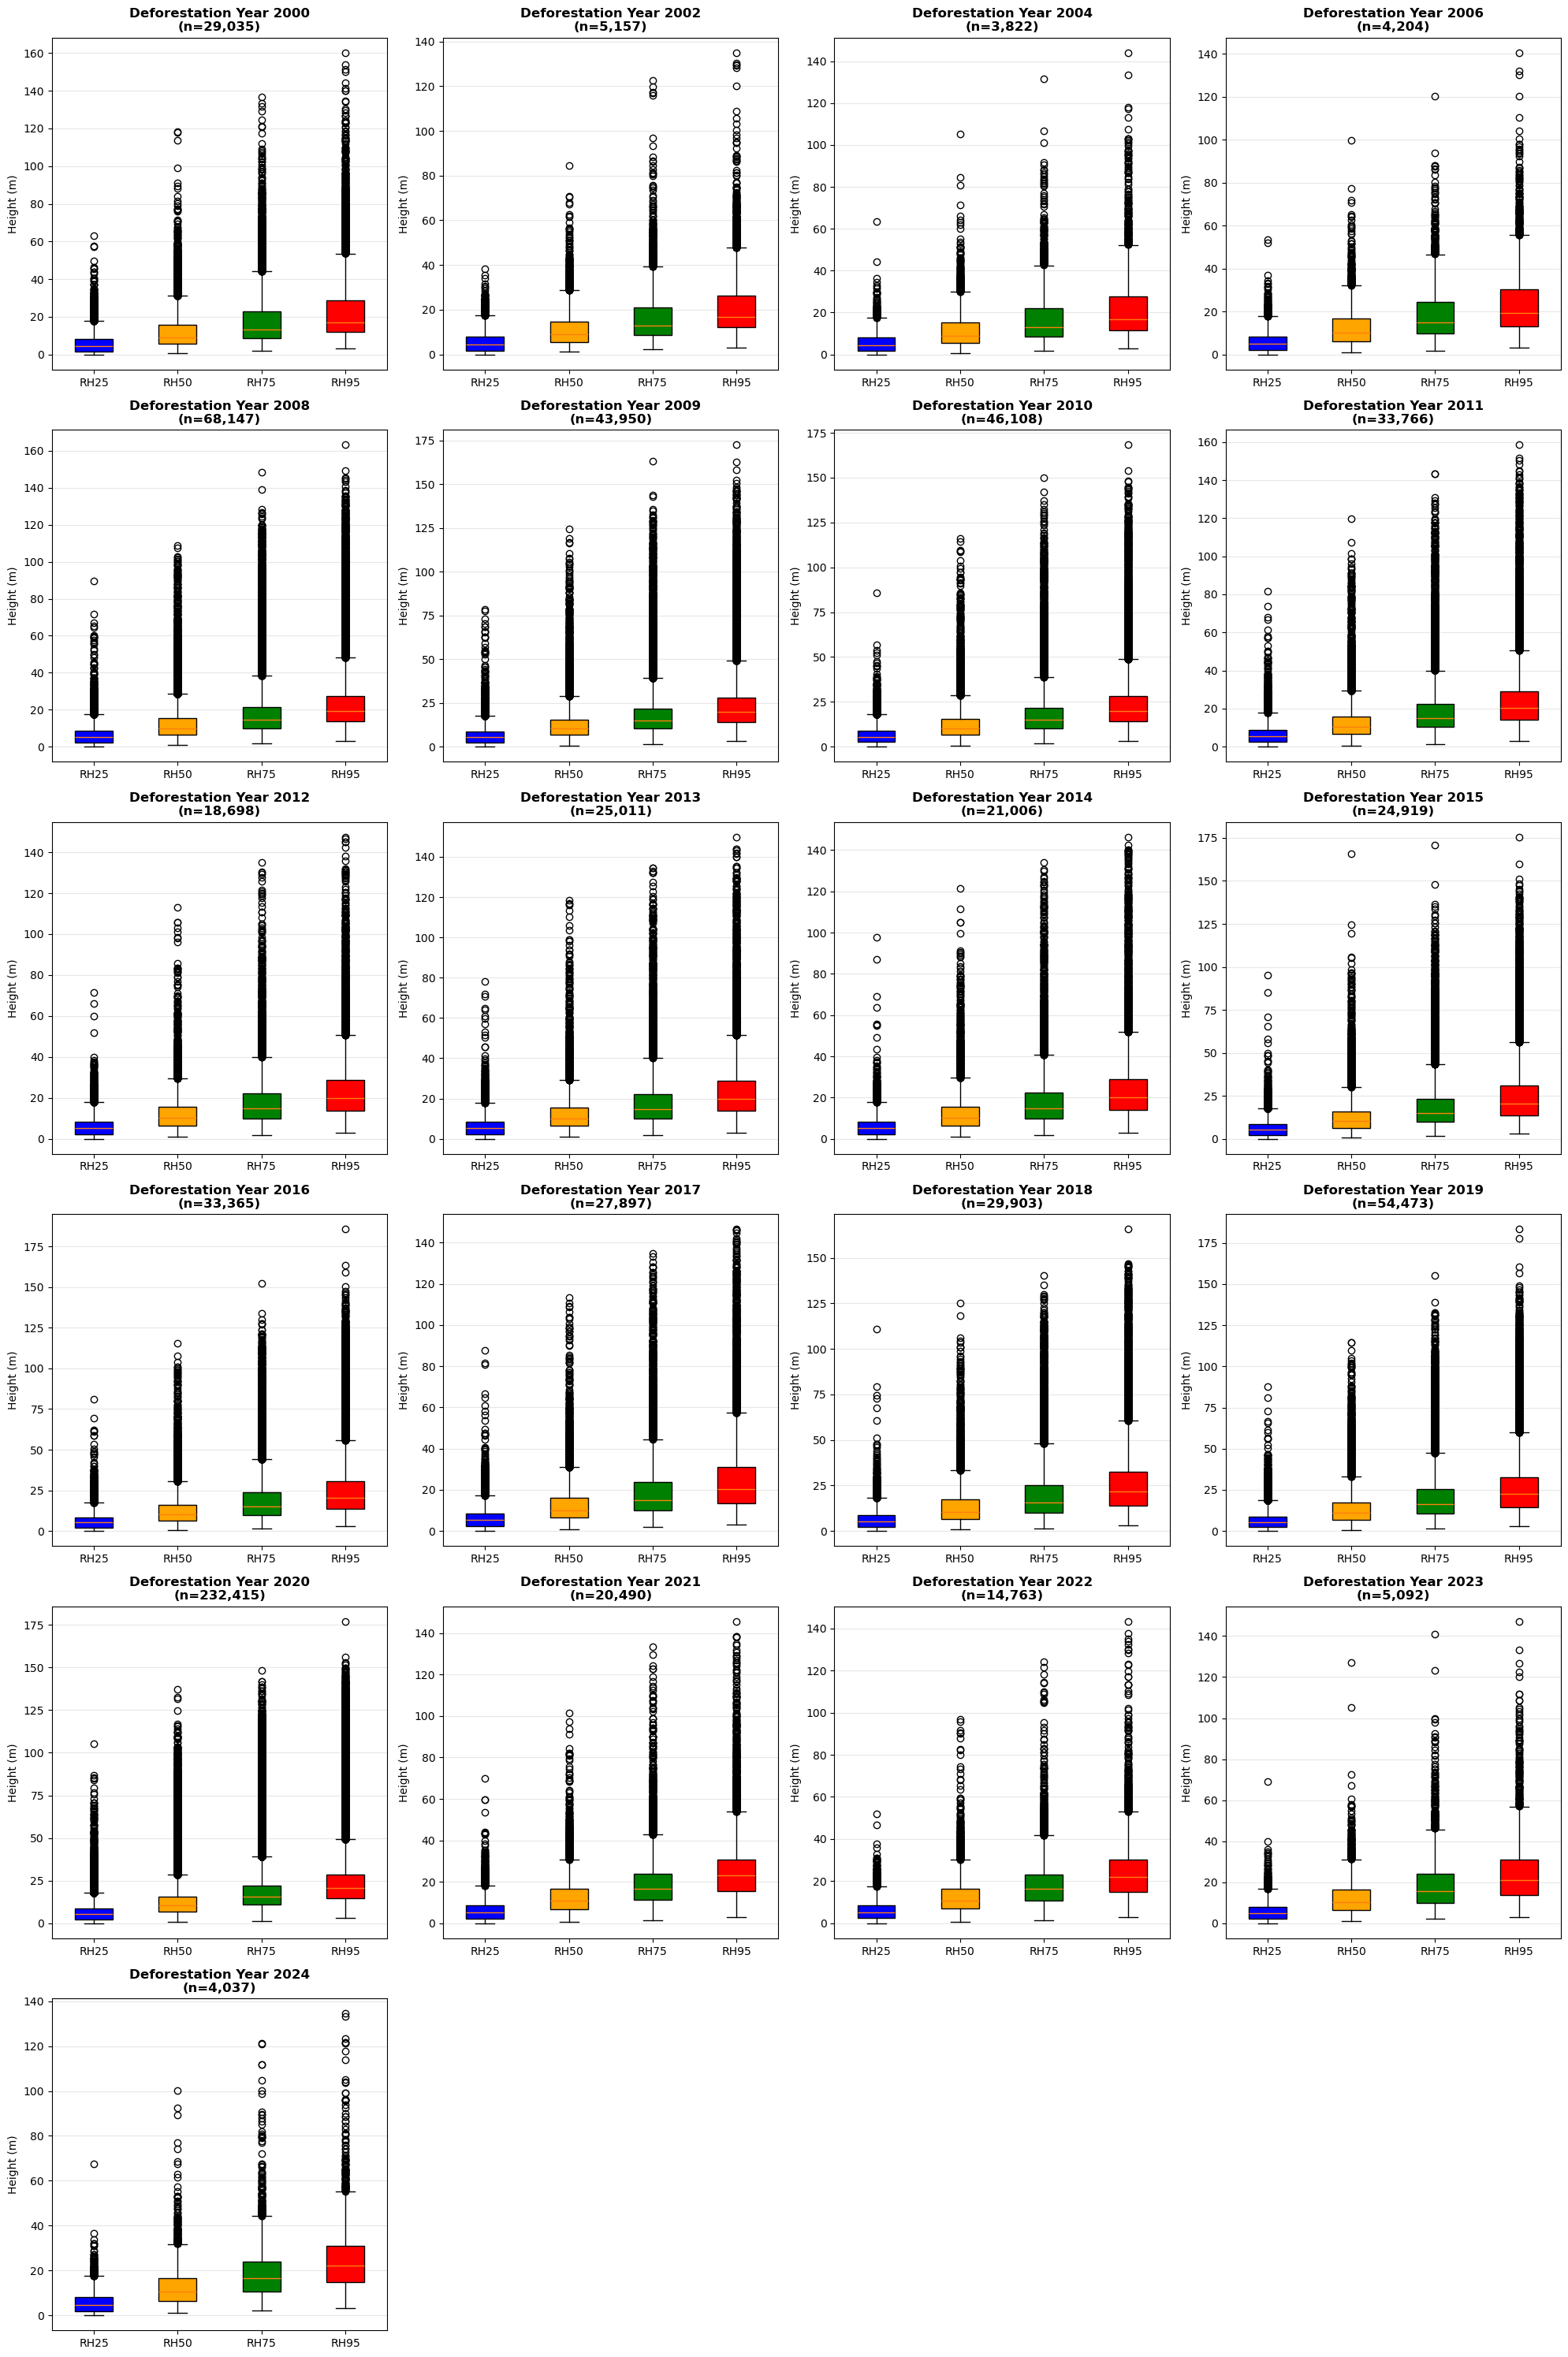


=== 5-NUMBER SUMMARY BY DEFORESTATION YEAR (NON-NEGATIVE RH ONLY) ===

Deforestation Year 2000 (n=29,035):
      rh25    rh50    rh75    rh95
min   0.00    0.81    1.94    3.03
25%   1.61    5.61    8.78   11.98
50%   4.53    9.20   13.18   17.15
75%   8.11   15.84   22.92   28.65
max  62.86  118.47  136.79  160.23 


Deforestation Year 2002 (n=5,157):
      rh25   rh50    rh75    rh95
min   0.00   1.15    2.35    3.10
25%   1.64   5.54    8.80   12.15
50%   4.51   9.03   12.88   16.86
75%   7.93  14.79   20.99   26.41
max  38.30  84.66  122.58  134.98 


Deforestation Year 2004 (n=3,822):
      rh25    rh50    rh75    rh95
min   0.00    0.74    1.76    3.03
25%   1.65    5.39    8.43   11.52
50%   4.48    9.06   12.95   16.84
75%   7.97   15.21   22.10   27.83
max  63.63  105.32  131.58  144.05 


Deforestation Year 2006 (n=4,204):
      rh25   rh50    rh75    rh95
min   0.00   0.89    1.86    3.25
25%   2.05   6.18    9.66   13.14
50%   5.04  10.26   14.98   19.32
75%   8.38  16.64 

In [29]:
# Boxplots for each deforestation year showing all 4 rh metrics
years = sorted(pos_rh_deforestation_data['deforestation_year'].unique())

# rows/columns needed for subplots
n_years = len(years)
n_cols = 4
n_rows = (n_years + n_cols - 1) // n_cols 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()  # Flatten to 1D array

for idx, year in enumerate(years):
    ax = axes[idx]
    
    # Get data for this year
    year_data = pos_rh_deforestation_data[pos_rh_deforestation_data['deforestation_year'] == year]
    data_by_metric = [year_data[metric] for metric in metrics]
    
    # create boxplot
    bp = ax.boxplot(data_by_metric, tick_labels=['RH25', 'RH50', 'RH75', 'RH95'], patch_artist=True)
    
    # color boxes
    for box, color in zip(bp['boxes'], colors):
        box.set_facecolor(color)
    
    ax.set_ylabel('Height (m)')
    ax.set_title(f'Deforestation Year {year}\n(n={len(year_data):,})', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

# remove unused plots
for j in range(len(years), n_cols*n_rows):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

print("\n=== 5-NUMBER SUMMARY BY DEFORESTATION YEAR (NON-NEGATIVE RH ONLY) ===\n")
for year in years:
    year_data = pos_rh_deforestation_data[pos_rh_deforestation_data['deforestation_year'] == year]
    print(f"Deforestation Year {year} (n={len(year_data):,}):")
    summary = year_data[metrics].describe().loc[['min', '25%', '50%', '75%', 'max']]
    print(summary.round(2), '\n\n')


In [23]:
# #Boxplots for the negative rh values in deforested points - can ignore this

# data = [only_negative_rh_deforested[m] for m in metrics]

# plt.figure(figsize=(10,6))
# plt.boxplot(data, labels=metrics)
# plt.ylabel('Height (m)')
# plt.title('Negative RH Values in Deforested Areas')
# plt.grid(axis='y')
# plt.show()

# print("\n5-Number Summary:")
# print(only_negative_rh_deforested[metrics].describe().loc[['min', '25%', '50%', '75%', 'max']])


In [24]:
# IGNORE - AI GENERATED FOR TESTING

# fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# metrics = ['rh25', 'rh50', 'rh75', 'rh95']
# titles = ['RH25 (25th percentile height)', 'RH50 (Median height)', 
#           'RH75 (75th percentile height)', 'RH95 (95th percentile height)']

# for idx, (metric, title) in enumerate(zip(metrics, titles)):
#     ax = axes[idx // 2, idx % 2]
    
#     # Create boxplot for each land class
#     land_classes = df['land_class'].unique()
#     data_by_class = [df[df['land_class'] == lc][metric].dropna() for lc in land_classes]
    
#     ax.boxplot(data_by_class, tick_labels=land_classes)
#     ax.set_ylabel('Height (m)')
#     ax.set_title(title)
#     ax.tick_params(axis='x', rotation=45)
#     ax.grid(axis='y', alpha=0.3)

# plt.tight_layout()
# plt.show()

# # Summary statistics
# print("\nCanopy Height Summary by Land Class:")
# print(df.groupby('land_class')[metrics].mean().round(2))